<a href="https://colab.research.google.com/github/32bikram/ML-Lab/blob/main/ASS3/ionosphere.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Gaussian**


TRAIN : TEST = 4 : 6

Confusion Matrix:
[[  0  76]
 [  0 135]]

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        76
           1       0.64      1.00      0.78       135

    accuracy                           0.64       211
   macro avg       0.32      0.50      0.39       211
weighted avg       0.41      0.64      0.50       211



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


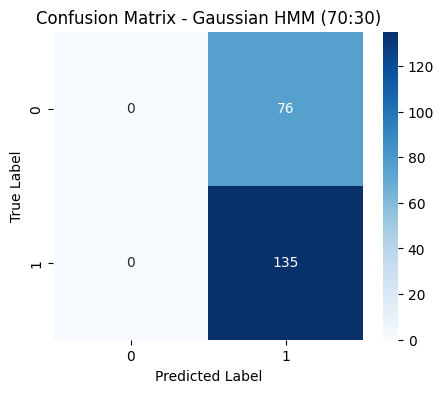


TRAIN : TEST = 7 : 3

Confusion Matrix:
[[30  8]
 [ 3 65]]

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85        38
           1       0.89      0.96      0.92        68

    accuracy                           0.90       106
   macro avg       0.90      0.87      0.88       106
weighted avg       0.90      0.90      0.89       106



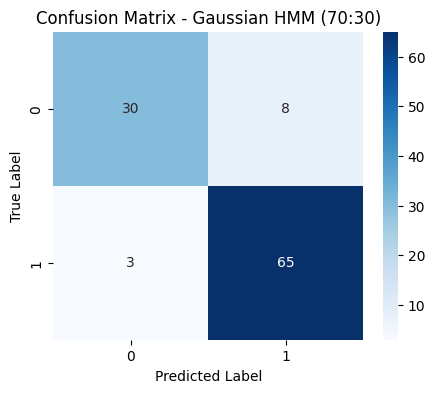


TRAIN : TEST = 8 : 2

Confusion Matrix:
[[22  3]
 [ 2 44]]

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        25
           1       0.94      0.96      0.95        46

    accuracy                           0.93        71
   macro avg       0.93      0.92      0.92        71
weighted avg       0.93      0.93      0.93        71



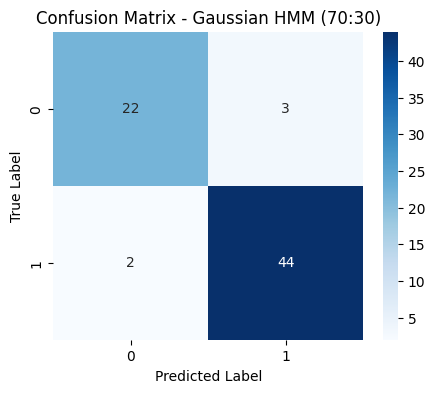

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset Preparation
dataset = pd.read_csv("/content/ionosphere.data", header=None)

X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

# Convert g/b into 0/1
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# 2. Imports
from sklearn.model_selection import train_test_split
from hmmlearn import hmm
from sklearn.metrics import classification_report, confusion_matrix

# 3. Function for Supervised HMM
def run_hmm(X, y, test_size):

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Convert DataFrames to NumPy arrays
    X_train = X_train.to_numpy()
    X_test = X_test.to_numpy()

    # Separate training data by class
    X_train_0 = X_train[y_train == 0]
    X_train_1 = X_train[y_train == 1]

    # Create HMM for each class
    model_0 = hmm.GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )

    model_1 = hmm.GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )

    # --------------------------------------
    # Train separately
    # --------------------------------------

    model_0.fit(X_train_0)
    model_1.fit(X_train_1)

    # --------------------------------------
    # Predict
    # --------------------------------------

    y_pred = []

    for sample in X_test:

        # sample has 34 features
        sample = sample.reshape(1, -1)

        # Likelihood under class 0 HMM
        score_0 = model_0.score(sample)

        # Likelihood under class 1 HMM
        score_1 = model_1.score(sample)

        # Higher likelihood = predicted class
        if score_0 > score_1:
            y_pred.append(0)
        else:
            y_pred.append(1)

    y_pred = np.array(y_pred)

    # --------------------------------------
    # Results
    # --------------------------------------

    print("\n==============================================")
    print(f"TRAIN : TEST = {int((1-test_size)*10)} : {int(test_size*10)}")
    print("==============================================")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nPerformance Evaluation:")
    print(classification_report(y_test, y_pred))

    import seaborn as sns

    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
      cm,
      annot=True,
      fmt="d",
      cmap="Blues",
      xticklabels=["0", "1"],
      yticklabels=["0", "1"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - Gaussian HMM (70:30)")

    plt.show()


# ==========================================
# 4. Run for 40:60
# ==========================================

run_hmm(X, y, 0.60)


# ==========================================
# 5. Run for 70:30
# ==========================================

run_hmm(X, y, 0.30)


# ==========================================
# 6. Run for 80:20
# ==========================================

run_hmm(X, y, 0.20)

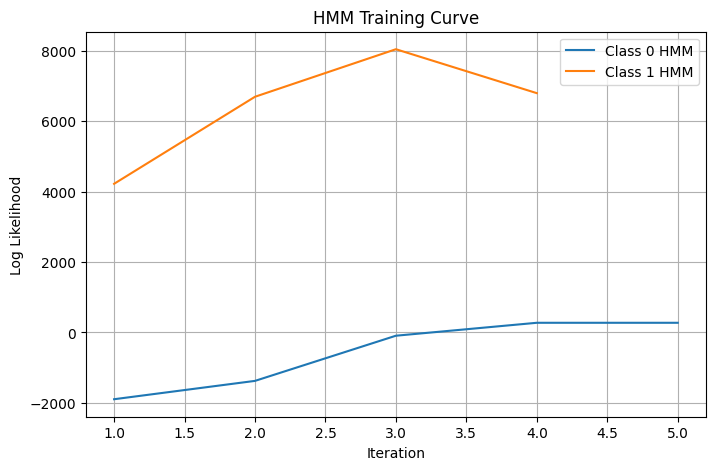

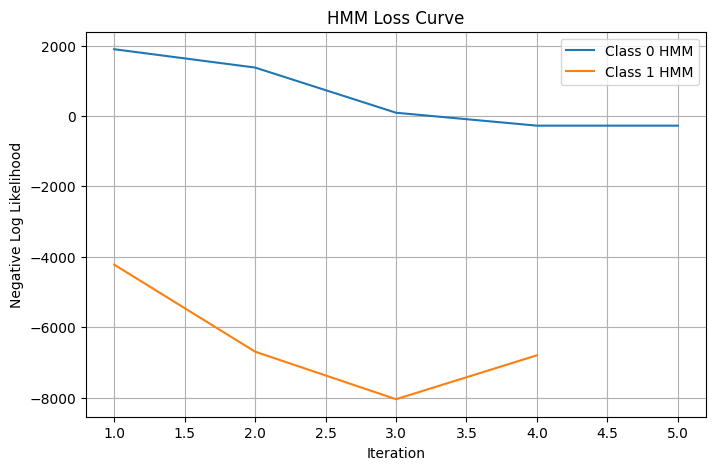


SUPERVISED GAUSSIAN HMM
TRAIN : TEST = 70 : 30

Confusion Matrix:
[[30  8]
 [ 3 65]]

Accuracy:
0.8962264150943396

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85        38
           1       0.89      0.96      0.92        68

    accuracy                           0.90       106
   macro avg       0.90      0.87      0.88       106
weighted avg       0.90      0.90      0.89       106



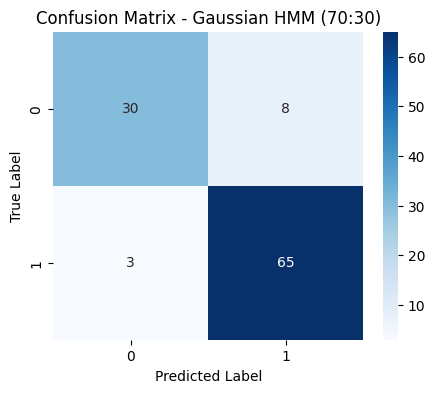

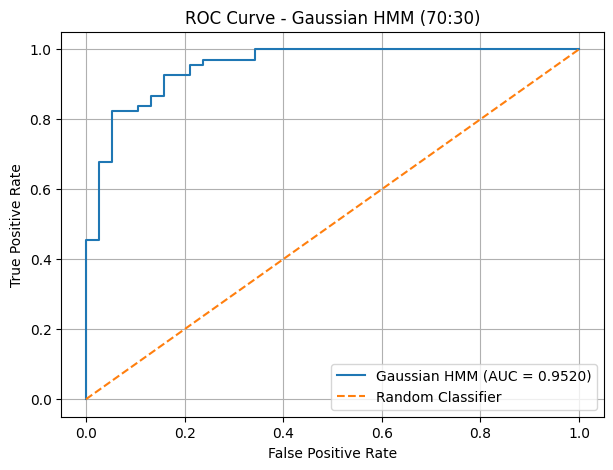


AUC: 0.9520123839009289


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Dataset Preparation
# ==========================================

dataset = pd.read_csv("/content/ionosphere.data", header=None)

X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

# Convert g/b into 0/1
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# ==========================================
# 2. Train-Test Split (70:30)
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Convert to NumPy
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

# ==========================================
# 3. Separate Training Data by Class
# ==========================================

X_train_0 = X_train[y_train == 0]
X_train_1 = X_train[y_train == 1]

# ==========================================
# 4. Create Two Gaussian HMMs
# ==========================================

from hmmlearn import hmm

model_0 = hmm.GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model_1 = hmm.GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

# ==========================================
# 5. Train
# ==========================================

model_0.fit(X_train_0)
model_1.fit(X_train_1)

# ==========================================
# 6. Training Curves
# ==========================================

history_0 = model_0.monitor_.history
history_1 = model_1.monitor_.history

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history_0) + 1),
    history_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(history_1) + 1),
    history_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Log Likelihood")
plt.title("HMM Training Curve")
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 7. Loss Curves
# ==========================================

loss_0 = [-x for x in history_0]
loss_1 = [-x for x in history_1]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(loss_0) + 1),
    loss_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(loss_1) + 1),
    loss_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Negative Log Likelihood")
plt.title("HMM Loss Curve")
plt.legend()
plt.grid()
plt.show()

# ==========================================
# 8. Prediction
# ==========================================

y_pred = []
decision_scores = []

for sample in X_test:

    sample = sample.reshape(1, -1)

    # Score from class 0 model
    score_0 = model_0.score(sample)

    # Score from class 1 model
    score_1 = model_1.score(sample)

    # Difference between the two likelihoods
    decision_score = score_1 - score_0

    decision_scores.append(decision_score)

    if score_0 > score_1:
        y_pred.append(0)
    else:
        y_pred.append(1)

y_pred = np.array(y_pred)
decision_scores = np.array(decision_scores)

# ==========================================
# 9. Confusion Matrix
# ==========================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

cm = confusion_matrix(y_test, y_pred)

print("\n==============================================")
print("SUPERVISED GAUSSIAN HMM")
print("TRAIN : TEST = 70 : 30")
print("==============================================")

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nPerformance Evaluation:")
print(classification_report(y_test, y_pred))

# ==========================================
# 10. Confusion Matrix Heatmap
# ==========================================

import seaborn as sns

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Gaussian HMM (70:30)")

plt.show()

# ==========================================
# 11. ROC Curve and AUC
# ==========================================

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    decision_scores
)

auc = roc_auc_score(
    y_test,
    decision_scores
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Gaussian HMM (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gaussian HMM (70:30)")
plt.legend()
plt.grid()

plt.show()

print("\nAUC:", auc)

**Multinomial without parameter**

Minimum value: 0
Maximum value: 9
Data type: int64

TRAIN : TEST = 8:2

Confusion Matrix:
[[18  7]
 [ 2 44]]

Accuracy:
0.8732394366197183

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80        25
           1       0.86      0.96      0.91        46

    accuracy                           0.87        71
   macro avg       0.88      0.84      0.85        71
weighted avg       0.88      0.87      0.87        71



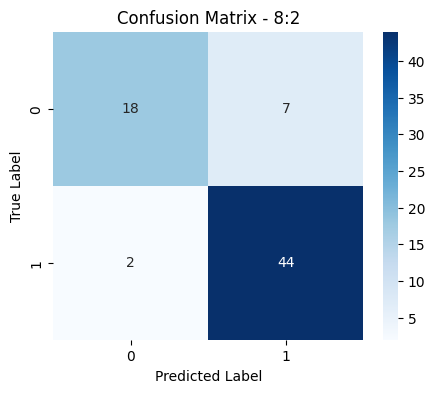


TRAIN : TEST = 7:3

Confusion Matrix:
[[31  7]
 [ 4 64]]

Accuracy:
0.8962264150943396

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        38
           1       0.90      0.94      0.92        68

    accuracy                           0.90       106
   macro avg       0.89      0.88      0.89       106
weighted avg       0.90      0.90      0.90       106



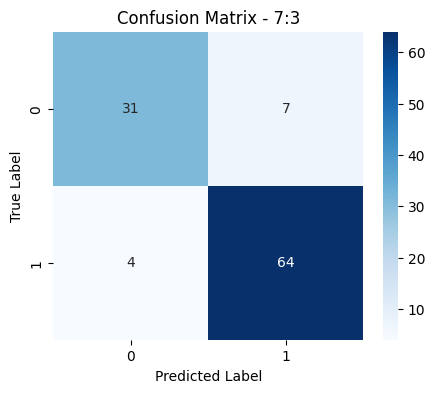


TRAIN : TEST = 6:4

Confusion Matrix:
[[42  9]
 [ 5 85]]

Accuracy:
0.900709219858156

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.89      0.82      0.86        51
           1       0.90      0.94      0.92        90

    accuracy                           0.90       141
   macro avg       0.90      0.88      0.89       141
weighted avg       0.90      0.90      0.90       141



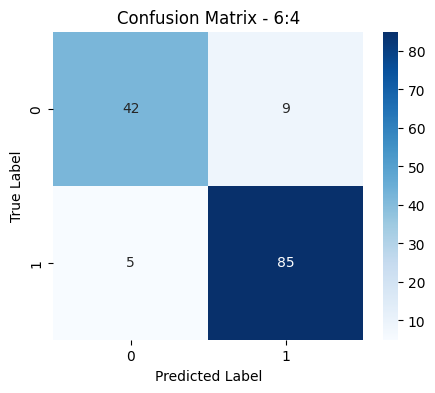

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset Preparation

dataset = pd.read_csv("/content/ionosphere.data", header=None)

X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

# Convert g/b into 0/1
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# 2. Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

# Convert values into integers from 0 to 9
X = (X * 9).astype(int)

# Make sure values are non-negative
X[X < 0] = 0

print("Minimum value:", X.min())
print("Maximum value:", X.max())
print("Data type:", X.dtype)

# 3. Function for HMM Classification
from sklearn.model_selection import train_test_split
from hmmlearn import hmm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


def run_hmm(test_size, split_name):

    # Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Separate data by class
    X_train_0 = X_train[y_train == 0]
    X_train_1 = X_train[y_train == 1]

    # Convert each row into a sequence
    X_train_0_seq = X_train_0.reshape(-1, 1)
    X_train_1_seq = X_train_1.reshape(-1, 1)

    # Each row has 34 observations
    lengths_0 = [34] * len(X_train_0)
    lengths_1 = [34] * len(X_train_1)

    # Create HMM models
    model_0 = hmm.CategoricalHMM(
        n_components=2,
        n_iter=1000,
        random_state=42
    )

    model_1 = hmm.CategoricalHMM(
        n_components=2,
        n_iter=1000,
        random_state=42
    )

    # Train the HMMs
    model_0.fit(
        X_train_0_seq,
        lengths=lengths_0
    )

    model_1.fit(
        X_train_1_seq,
        lengths=lengths_1
    )

    # Prediction
    y_pred = []

    for sample in X_test:

        # Convert one row into a sequence of 34 observations
        sample = sample.reshape(-1, 1)

        # Likelihood under both models
        score_0 = model_0.score(sample)
        score_1 = model_1.score(sample)

        # Choose class with higher likelihood
        if score_0 > score_1:
            y_pred.append(0)
        else:
            y_pred.append(1)

    y_pred = np.array(y_pred)

    # Evaluation
    cm = confusion_matrix(y_test, y_pred)

    print("\n==============================================")
    print("TRAIN : TEST =", split_name)
    print("==============================================")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nAccuracy:")
    print(accuracy_score(y_test, y_pred))

    print("\nPerformance Evaluation:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Heatmap
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["0", "1"],
        yticklabels=["0", "1"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - " + split_name)
    plt.show()

# 4. 8:2 Split
run_hmm(0.20, "8:2")

# 5. 7:3 Split
run_hmm(0.30, "7:3")

# 6. 6:4 Split
run_hmm(0.40, "6:4")

Minimum value: 0
Maximum value: 9
Data type: int64


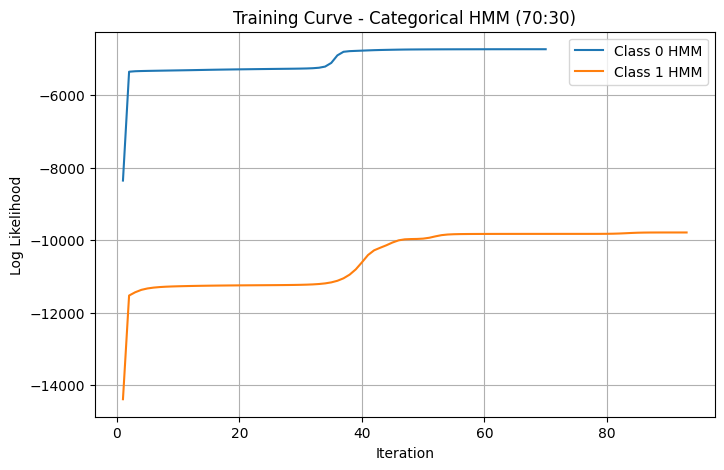

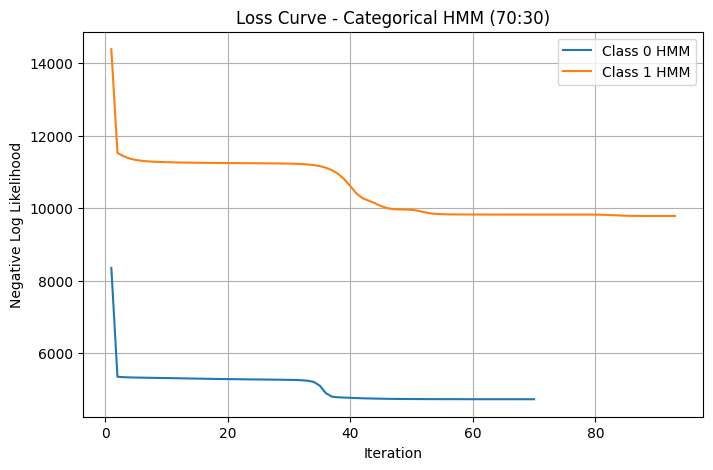


CATEGORICAL HMM
TRAIN : TEST = 70 : 30

Confusion Matrix:
[[31  7]
 [ 4 64]]

Accuracy:
0.8962264150943396

Performance Evaluation:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        38
           1       0.90      0.94      0.92        68

    accuracy                           0.90       106
   macro avg       0.89      0.88      0.89       106
weighted avg       0.90      0.90      0.90       106



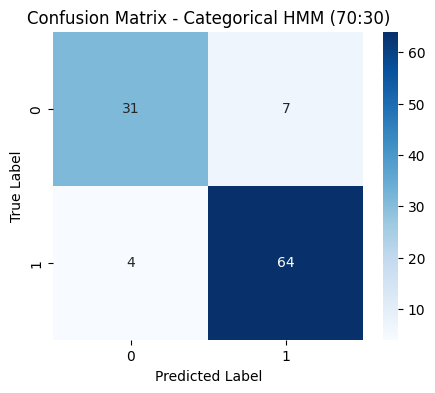

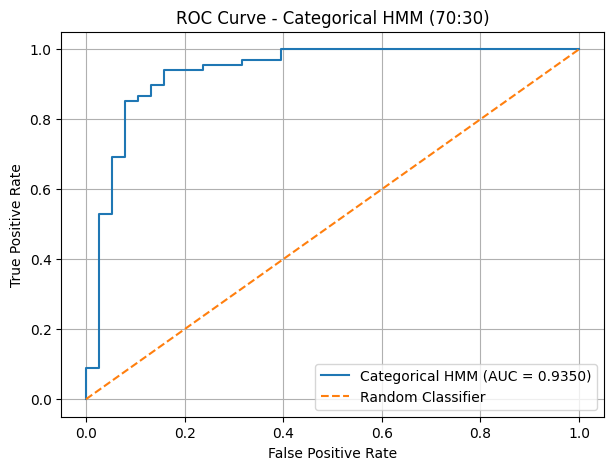


AUC: 0.934984520123839


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset Preparation

dataset = pd.read_csv("/content/ionosphere.data", header=None)

X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

# Convert g/b into 0/1
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# 2. Scale the data

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = scaler.fit_transform(X)

# Convert values into integers from 0 to 9
X = (X * 9).astype(int)

# Make sure values are non-negative
X[X < 0] = 0

print("Minimum value:", X.min())
print("Maximum value:", X.max())
print("Data type:", X.dtype)

# 3. Train-Test Split (70:30)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 4. Separate data by class

X_train_0 = X_train[y_train == 0]
X_train_1 = X_train[y_train == 1]

# 5. Convert each row into a sequence

X_train_0_seq = X_train_0.reshape(-1, 1)
X_train_1_seq = X_train_1.reshape(-1, 1)

# Each row contains 34 observations
lengths_0 = [34] * len(X_train_0)
lengths_1 = [34] * len(X_train_1)

# 6. Create HMM models

from hmmlearn import hmm

model_0 = hmm.CategoricalHMM(
    n_components=2,
    n_iter=1000,
    random_state=42
)

model_1 = hmm.CategoricalHMM(
    n_components=2,
    n_iter=1000,
    random_state=42
)

# 7. Train the HMMs

model_0.fit(
    X_train_0_seq,
    lengths=lengths_0
)

model_1.fit(
    X_train_1_seq,
    lengths=lengths_1
)

# 8. Training Curves

history_0 = list(model_0.monitor_.history)
history_1 = list(model_1.monitor_.history)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history_0) + 1),
    history_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(history_1) + 1),
    history_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Log Likelihood")
plt.title("Training Curve - Categorical HMM (70:30)")
plt.legend()
plt.grid()
plt.show()


# 9. Loss Curves

loss_0 = [-x for x in history_0]
loss_1 = [-x for x in history_1]

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(loss_0) + 1),
    loss_0,
    label="Class 0 HMM"
)

plt.plot(
    range(1, len(loss_1) + 1),
    loss_1,
    label="Class 1 HMM"
)

plt.xlabel("Iteration")
plt.ylabel("Negative Log Likelihood")
plt.title("Loss Curve - Categorical HMM (70:30)")
plt.legend()
plt.grid()
plt.show()

# 10. Prediction

y_pred = []

# Continuous scores for ROC
decision_scores = []

for sample in X_test:

    # Convert sample into a sequence of 34 observations
    sample = sample.reshape(-1, 1)

    # Score under class 0 model
    score_0 = model_0.score(sample)

    # Score under class 1 model
    score_1 = model_1.score(sample)

    # Continuous classification score
    decision_score = score_1 - score_0

    decision_scores.append(decision_score)

    # Higher likelihood = predicted class
    if score_0 > score_1:
        y_pred.append(0)
    else:
        y_pred.append(1)

y_pred = np.array(y_pred)
decision_scores = np.array(decision_scores)

# 11. Evaluation

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

cm = confusion_matrix(y_test, y_pred)

print("\n==============================================")
print("CATEGORICAL HMM")
print("TRAIN : TEST = 70 : 30")
print("==============================================")

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nPerformance Evaluation:")
print(classification_report(y_test, y_pred))

# 12. Confusion Matrix Heatmap

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Categorical HMM (70:30)")
plt.show()

# 13. ROC Curve and AUC

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    decision_scores
)

auc = roc_auc_score(
    y_test,
    decision_scores
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Categorical HMM (AUC = {auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Categorical HMM (70:30)")
plt.legend()
plt.grid()
plt.show()

print("\nAUC:", auc)